In [11]:
# 1. Install Yahoo Finance library to fetch live market data
!pip install yfinance

# 2. Import core libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 3. Download daily Gold Futures prices ('GC=F') for the past 5 years
print("Fetching gold price data...")
gold_data = yf.download('GC=F', start='2021-01-01', end='2026-09-01')

# 4. View the first 5 days of data
gold_data.head()

/tmp/ipykernel_7558/681129915.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download('GC=F', start='2021-01-01', end='2026-09-01')
[*********************100%***********************]  1 of 1 completed

Fetching gold price data...


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2021-01-04,1946.599976,1948.699951,1906.099976,1908.199951,273370
2021-01-05,1954.400024,1957.000000,1938.400024,1946.000000,201945
2021-01-06,1908.599976,1962.500000,1902.599976,1952.800049,366605
2021-01-07,1913.599976,1929.599976,1907.500000,1921.500000,199982
2021-01-08,1835.400024,1918.400024,1827.800049,1915.199951,443506


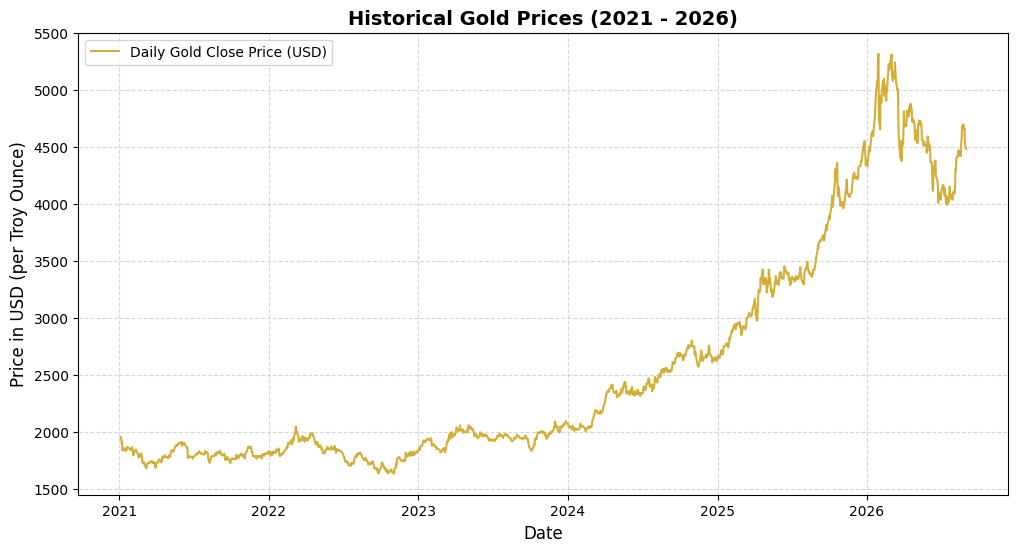

In [12]:
# Set the size of the plot
plt.figure(figsize=(12, 6))

# Plot the 'Close' price (the final trading price of gold for each day)
plt.plot(gold_data['Close'], label='Daily Gold Close Price (USD)', color='#D4AF37', linewidth=1.5)

# Add title and labels
plt.title('Historical Gold Prices (2021 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price in USD (per Troy Ounce)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Display the chart
plt.show()

/tmp/ipykernel_7558/751693789.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_test = adfuller(close_price)


=== Augmented Dickey-Fuller (ADF) Test ===
ADF Test Statistic : 0.6856
p-value            : 0.9895
>> Conclusion: p-value > 0.05. The data is NON-STATIONARY. We must difference it!



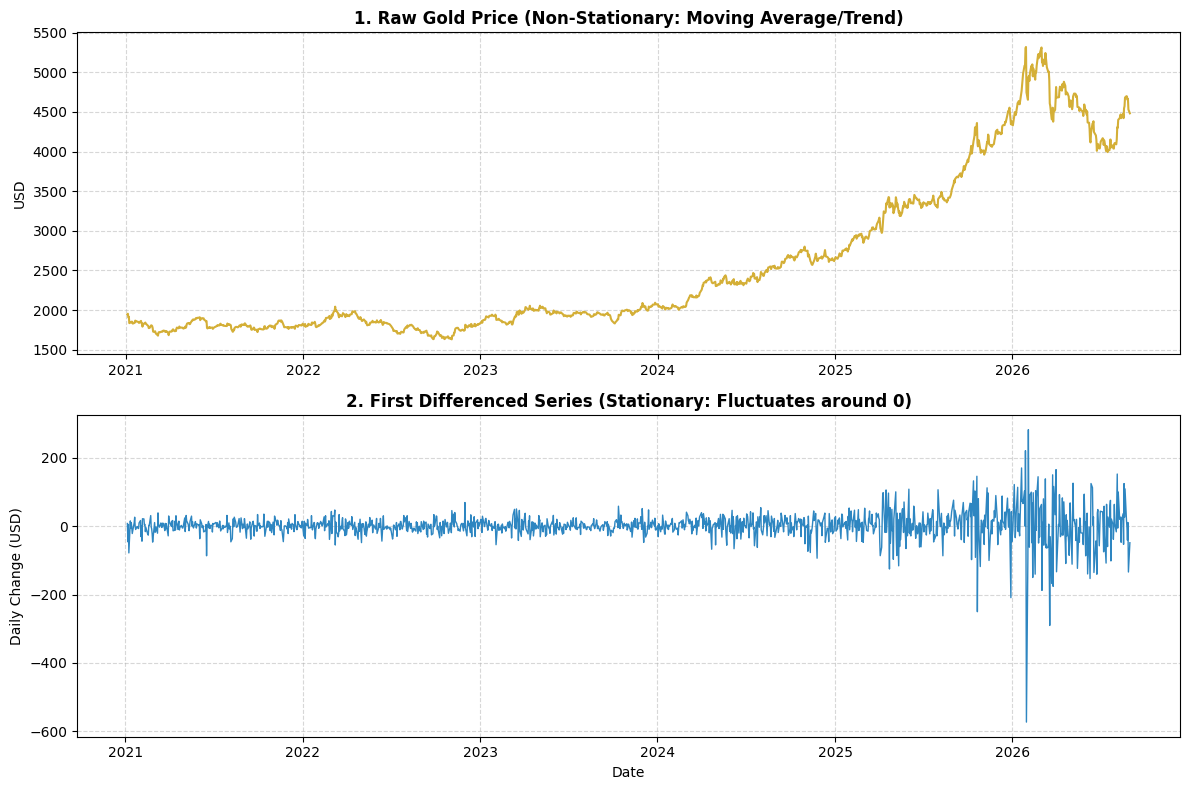

In [13]:
from statsmodels.tsa.stattools import adfuller

# 1. Clean and extract the Close price (handling yfinance column structure)
if isinstance(gold_data.columns, pd.MultiIndex):
    close_price = gold_data['Close']['GC=F'].dropna()
else:
    close_price = gold_data['Close'].dropna()

# 2. Run the Augmented Dickey-Fuller (ADF) Test on raw prices
adf_test = adfuller(close_price)
print("=== Augmented Dickey-Fuller (ADF) Test ===")
print(f"ADF Test Statistic : {adf_test[0]:.4f}")
print(f"p-value            : {adf_test[1]:.4f}")

if adf_test[1] > 0.05:
    print(">> Conclusion: p-value > 0.05. The data is NON-STATIONARY. We must difference it!\n")
else:
    print(">> Conclusion: p-value <= 0.05. The data is STATIONARY.\n")

# 3. Apply First-Order Differencing: (Today's Price - Yesterday's Price)
diff_price = close_price.diff().dropna()

# 4. Plot Original vs Differenced Series side-by-side
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Subplot 1: Raw Price
axes[0].plot(close_price, color='#D4AF37', linewidth=1.5)
axes[0].set_title('1. Raw Gold Price (Non-Stationary: Moving Average/Trend)', fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: First Difference (Daily Changes)
axes[1].plot(diff_price, color='#2E86C1', linewidth=1)
axes[1].set_title('2. First Differenced Series (Stationary: Fluctuates around 0)', fontweight='bold')
axes[1].set_ylabel('Daily Change (USD)')
axes[1].set_xlabel('Date')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7558/2837514403.py:11: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_log = adfuller(log_returns)


=== ADF Test on Log Returns ===
ADF Statistic : -15.3420
p-value       : 3.8195e-28 (Extremely close to 0!)
>> Result: Log returns are perfectly stationary!



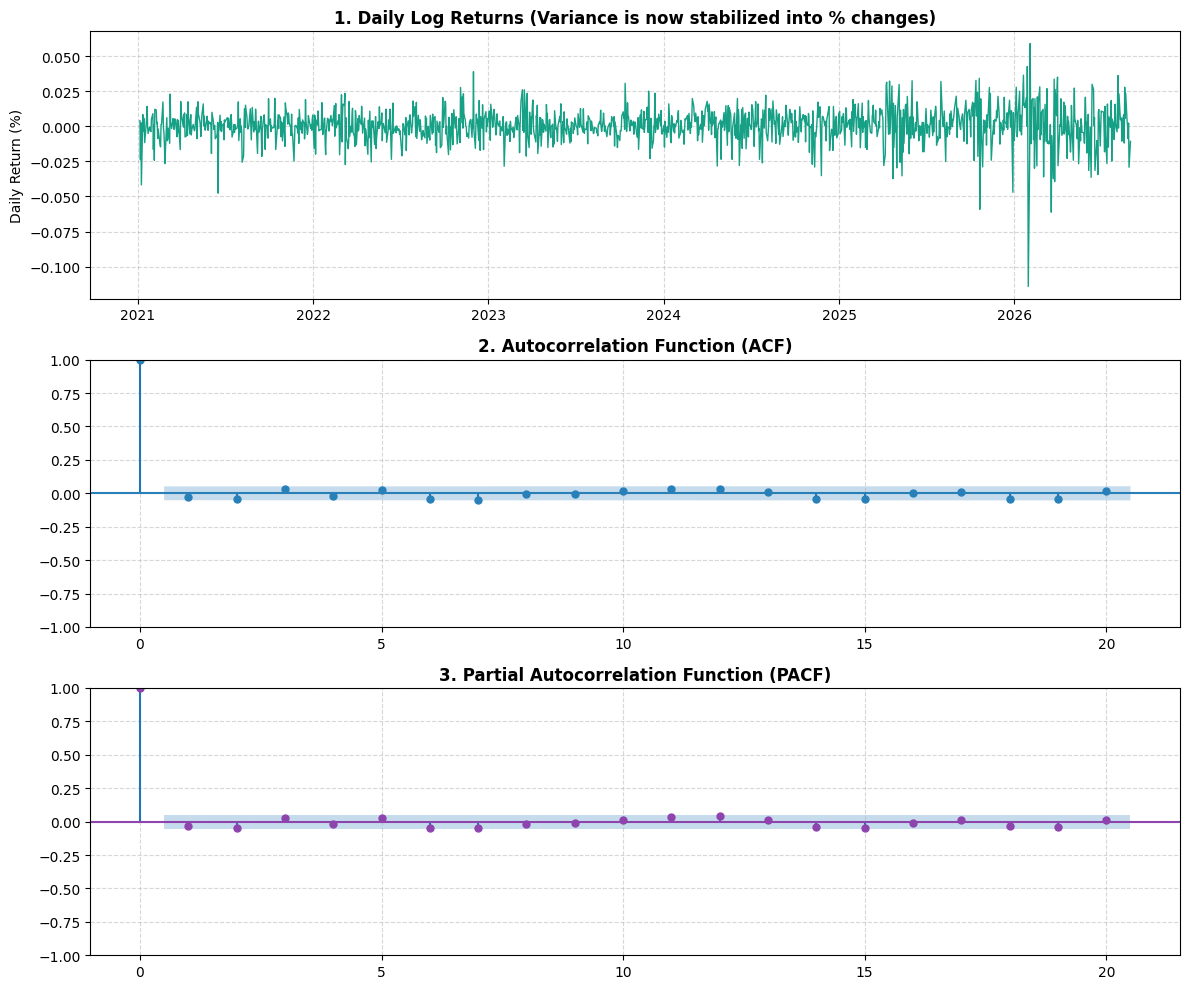

In [14]:
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Take the Natural Log of Gold Prices
log_price = np.log(close_price)

# 2. Compute Log Returns (First Difference of Log Prices)
log_returns = log_price.diff().dropna()

# 3. Test Stationarity of Log Returns
adf_log = adfuller(log_returns)
print("=== ADF Test on Log Returns ===")
print(f"ADF Statistic : {adf_log[0]:.4f}")
print(f"p-value       : {adf_log[1]:.4e} (Extremely close to 0!)")
print(">> Result: Log returns are perfectly stationary!\n")

# 4. Plot Log Returns + ACF + PACF
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Subplot 1: Log Returns
axes[0].plot(log_returns, color='#16A085', linewidth=1)
axes[0].set_title('1. Daily Log Returns (Variance is now stabilized into % changes)', fontweight='bold')
axes[0].set_ylabel('Daily Return (%)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: ACF Plot (Used to find 'q' - Moving Average order)
plot_acf(log_returns, lags=20, ax=axes[1], color='#2980B9')
axes[1].set_title('2. Autocorrelation Function (ACF)', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Subplot 3: PACF Plot (Used to find 'p' - Autoregressive order)
plot_pacf(log_returns, lags=20, ax=axes[2], color='#8E44AD', method='ywm')
axes[2].set_title('3. Partial Autocorrelation Function (PACF)', fontweight='bold')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

=== Comparing Candidate ARIMA Models (Lowest AIC Wins) ===
ARIMA(0, 1, 0) - AIC: -8293.98
ARIMA(1, 1, 0) - AIC: -8294.39
ARIMA(0, 1, 1) - AIC: -8294.63
ARIMA(1, 1, 1) - AIC: -8293.60

>> Optimal Model Selected: ARIMA(0, 1, 1) with AIC: -8294.63

=== Model Performance on Test Data ===
Mean Absolute Percentage Error (MAPE): 8.26%
Root Mean Squared Error (RMSE): $385.53 USD


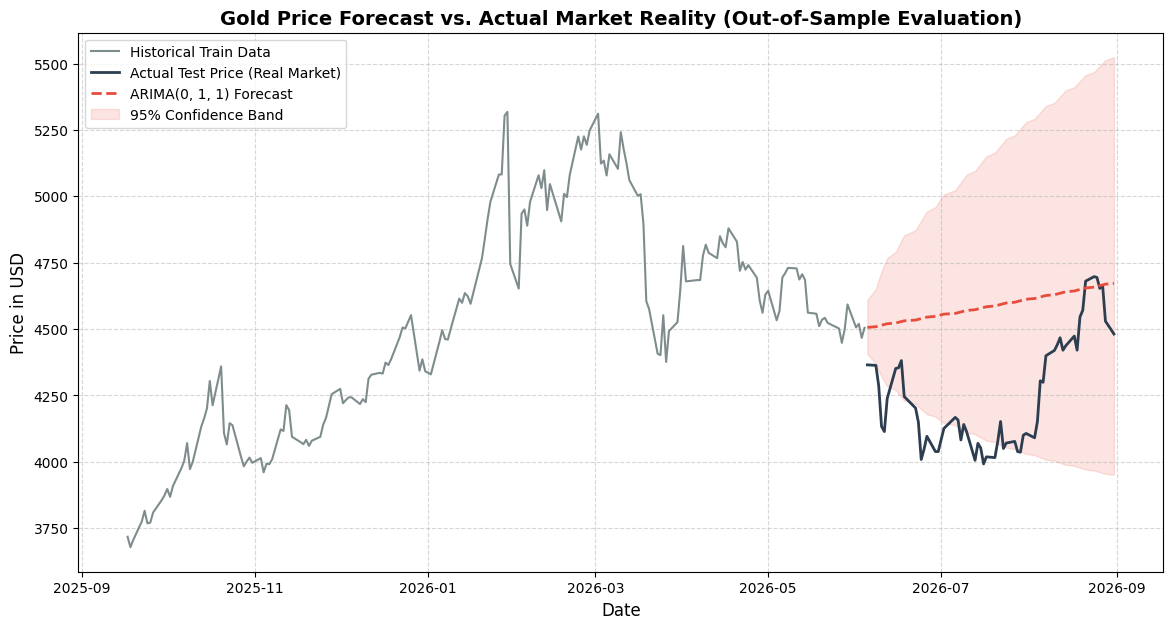

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. Train / Test Split (Keep last 60 trading days as Test Data)
test_days = 60
train_data = close_price.iloc[:-test_days]
test_data = close_price.iloc[-test_days:]

# Take natural log of training data
train_log = np.log(train_data)

# 2. Fit Candidate ARIMA Models using raw values (avoids weekend date-gap bugs)
candidate_orders = [(0, 1, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1)]
best_aic = float("inf")
best_order = None
best_model = None

print("=== Comparing Candidate ARIMA Models (Lowest AIC Wins) ===")
for order in candidate_orders:
    try:
        # We pass .values so statsmodels doesn't get confused by missing weekend dates
        model = ARIMA(train_log.values, order=order, trend='t')
        fitted = model.fit()
        print(f"ARIMA{order} - AIC: {fitted.aic:.2f}")
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = order
            best_model = fitted
    except Exception as e:
        continue

print(f"\n>> Optimal Model Selected: ARIMA{best_order} with AIC: {best_aic:.2f}\n")

# 3. Forecast the next 60 trading days on Log Scale
forecast_res = best_model.get_forecast(steps=test_days)
forecast_log = forecast_res.predicted_mean
conf_int_log = forecast_res.conf_int(alpha=0.05) # 95% confidence interval

# 4. Invert Logs back to actual US Dollars: exp(log_val)
# Re-attach the real test dates to the predictions for plotting
forecast_usd = pd.Series(np.exp(forecast_log), index=test_data.index)
lower_bound_usd = pd.Series(np.exp(conf_int_log[:, 0]), index=test_data.index)
upper_bound_usd = pd.Series(np.exp(conf_int_log[:, 1]), index=test_data.index)

# 5. Evaluate Accuracy
mape = mean_absolute_percentage_error(test_data, forecast_usd) * 100
rmse = np.sqrt(mean_squared_error(test_data, forecast_usd))
print(f"=== Model Performance on Test Data ===")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f} USD")

# 6. Plot Actual vs Forecasted Gold Prices
plt.figure(figsize=(14, 7))

# Plot recent train context (last 180 days for clean visual)
plt.plot(train_data.iloc[-180:], label='Historical Train Data', color='#7F8C8D', linewidth=1.5)

# Plot actual test price (real market)
plt.plot(test_data, label='Actual Test Price (Real Market)', color='#2C3E50', linewidth=2)

# Plot our ARIMA forecast
plt.plot(forecast_usd, label=f'ARIMA{best_order} Forecast', color='#E74C3C', linestyle='--', linewidth=2)

# Plot 95% Confidence Interval band
plt.fill_between(test_data.index, lower_bound_usd, upper_bound_usd, color='#E74C3C', alpha=0.15, label='95% Confidence Band')

plt.title('Gold Price Forecast vs. Actual Market Reality (Out-of-Sample Evaluation)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price in USD', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

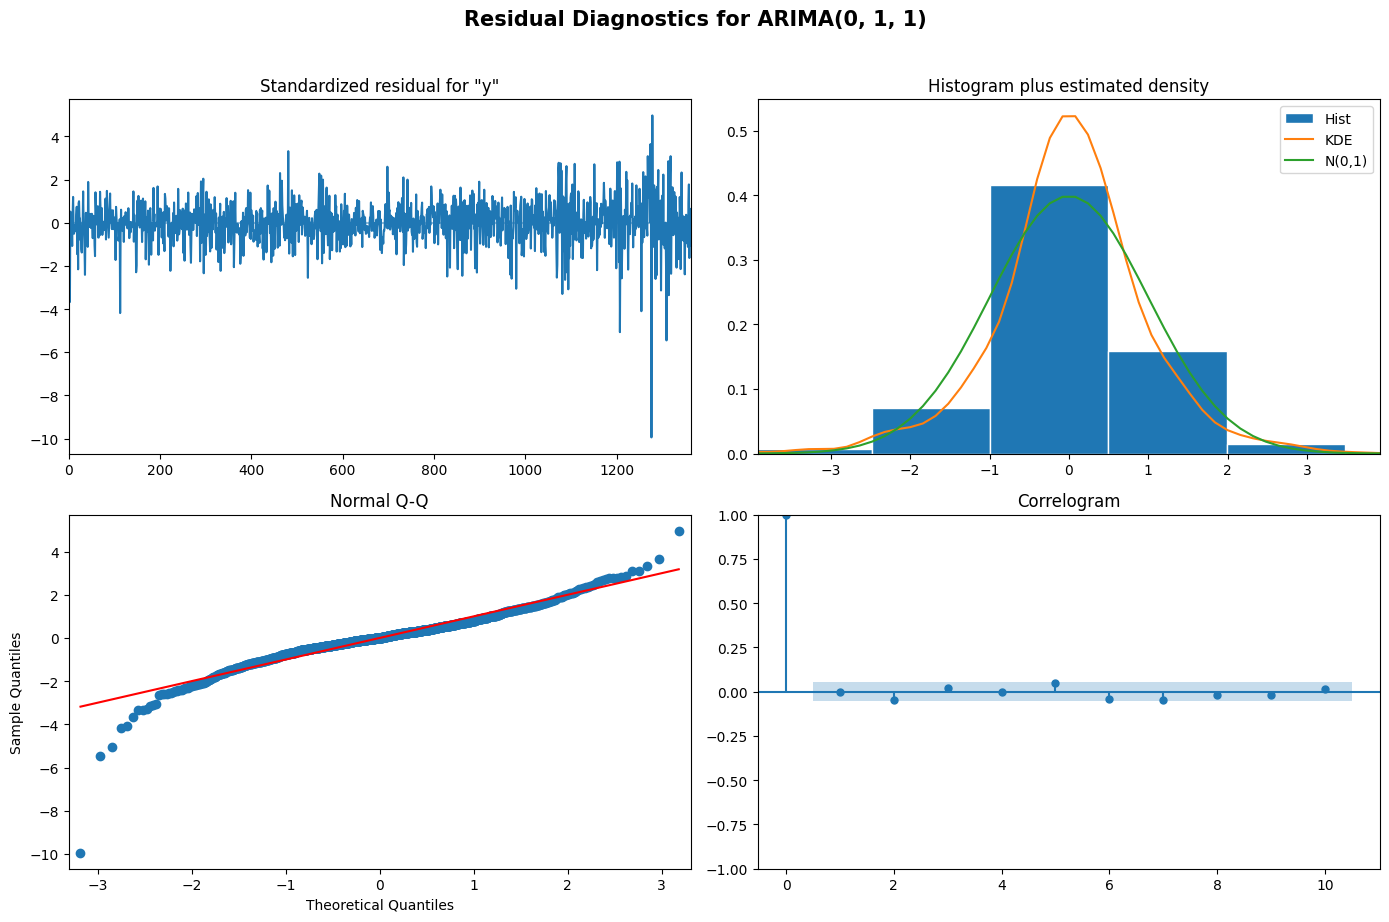

In [16]:
# 1. Generate Residual Diagnostics for the Best Model
fig = best_model.plot_diagnostics(figsize=(14, 9))

plt.suptitle(f'Residual Diagnostics for ARIMA{best_order}', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()